In [26]:
# Import libraries

import pandas as pd
import seaborn as sns
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
plt.style.use('ggplot')
from matplotlib.pyplot import figure

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (10,6) # Adjusts the configuration of the plots we wil create




In [27]:
#Read in the data

df = pd.read_csv(r'C:\Users\aunwa\Downloads\archive (3)\movies_new.csv', encoding='ISO-8859-1')

In [28]:
# let's look at the data

df.head()

,budget,company,country,director,genre,gross,name,rating,released,runtime,score,star,writer,year
0,8000000.0,Columbia Pictures Corporation,USA,Rob Reiner,Adventure,52287414.0,Stand by Me,R,1986-08-22,89,8.1,Wil Wheaton,Stephen King,1986
1,15000000.0,Paramount Pictures,USA,Tony Scott,Action,179800601.0,Top Gun,PG,1986-05-16,110,6.9,Tom Cruise,Jim Cash,1986
2,18500000.0,Twentieth Century Fox Film Corporation,USA,James Cameron,Action,85160248.0,Aliens,R,1986-07-18,137,8.4,Sigourney Weaver,James Cameron,1986
3,6000000.0,Paramount Pictures,USA,John Hughes,Comedy,70136369.0,Ferris Bueller's Day Off,PG-13,1986-06-11,103,7.8,Matthew Broderick,John Hughes,1986
4,9000000.0,Paramount Pictures,USA,Howard Deutch,Comedy,40471663.0,Pretty in Pink,PG-13,1986-02-28,96,6.8,Molly Ringwald,John Hughes,1986


In [29]:
# Check for missing data

for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    print('{} - {}%'.format(col, pct_missing))

budget - 0.0%
company - 0.0%
country - 0.0%
director - 0.0%
genre - 0.0%
gross - 0.0%
name - 0.0%
rating - 0.0%
released - 0.0%
runtime - 0.0%
score - 0.0%
star - 0.0%
writer - 0.0%
year - 0.0%


In [30]:
#Data Cleaning

# Data types

df.dtypes


budget      float64
company      object
country      object
director     object
genre        object
gross       float64
name         object
rating       object
released     object
runtime       int64
score       float64
star         object
writer       object
year          int64
dtype: object

In [31]:
# Change budget and gross column to a whole number 

df['budget'] = df['budget'].astype('int64')
df['gross'] = df['gross'].astype('int64')

In [32]:
df.describe()

,budget,gross,runtime,score,year
count,3.100000e+03,3.100000e+03,3100.000000,3100.000000,3100.000000
mean,3.874657e+07,5.960057e+07,110.644839,6.637032,2001.000000
std,4.576608e+07,7.540999e+07,19.135410,0.935801,8.945715
min,0.000000e+00,1.800000e+03,69.000000,1.900000,1986.000000
25%,6.150000e+06,1.300807e+07,97.000000,6.100000,1993.000000
50%,2.400000e+07,3.585622e+07,107.000000,6.700000,2001.000000
75%,5.225000e+07,7.558639e+07,121.000000,7.300000,2009.000000
max,3.000000e+08,9.366622e+08,271.000000,9.300000,2016.000000


In [34]:
# create column with correct year of relaease 

df['correct_year'] = df['released'].astype(str).str[:4]

df.head()

,budget,company,country,director,genre,gross,name,rating,released,runtime,score,star,writer,year,correct_year
0,8000000,Columbia Pictures Corporation,USA,Rob Reiner,Adventure,52287414,Stand by Me,R,1986-08-22,89,8.1,Wil Wheaton,Stephen King,1986,1986
1,15000000,Paramount Pictures,USA,Tony Scott,Action,179800601,Top Gun,PG,1986-05-16,110,6.9,Tom Cruise,Jim Cash,1986,1986
2,18500000,Twentieth Century Fox Film Corporation,USA,James Cameron,Action,85160248,Aliens,R,1986-07-18,137,8.4,Sigourney Weaver,James Cameron,1986,1986
3,6000000,Paramount Pictures,USA,John Hughes,Comedy,70136369,Ferris Bueller's Day Off,PG-13,1986-06-11,103,7.8,Matthew Broderick,John Hughes,1986,1986
4,9000000,Paramount Pictures,USA,Howard Deutch,Comedy,40471663,Pretty in Pink,PG-13,1986-02-28,96,6.8,Molly Ringwald,John Hughes,1986,1986


In [35]:
# Order data using the revenue (revenue)

df_sort = df.sort_values(by=['gross'], inplace=False, ascending=False)

In [36]:
# Display all the rows of the data
pd.set_option('display.max_rows', None)

In [37]:
df['company'].is_unique

False

In [42]:
#drop any duplicates

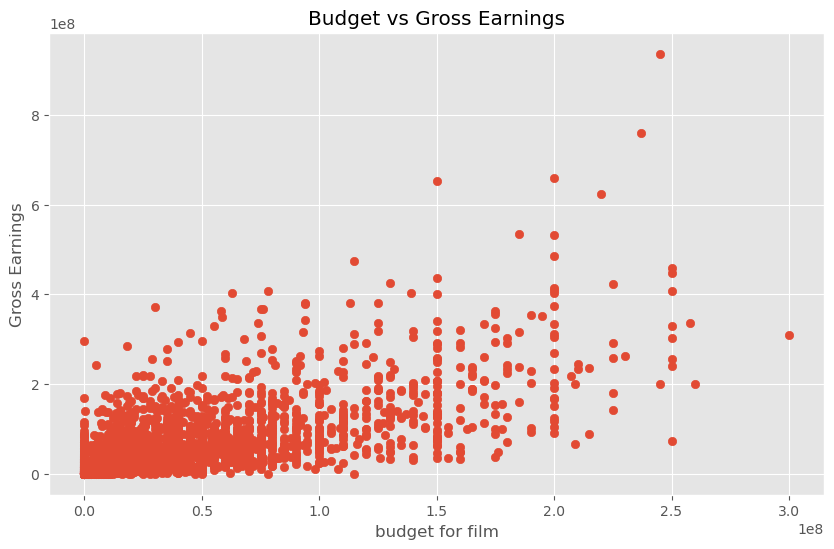

In [22]:
#Checking Correlation with the gross revenue
# Scatter plot with budget vs gross using matplotLib

plt.scatter(x=df['budget'], y=df['gross'])

plt.title('Budget vs Gross Earnings')

plt.xlabel('budget for film')
plt.ylabel('Gross Earnings')

plt.show()

<Axes: xlabel='budget', ylabel='gross'>

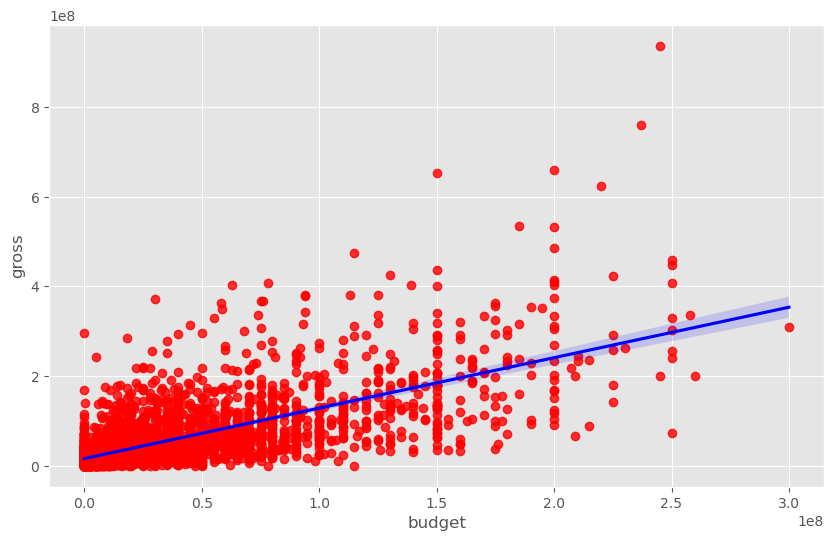

In [23]:
# Budget vs Gross earning using Seaborn

sns.regplot(x='budget', y='gross', data=df, scatter_kws={"color":"red"}, line_kws={"color":"blue"})

In [17]:
# Checking for correlation


In [24]:
#Exclude non-numeric columns
df_numeric = df.select_dtypes(include=['number'])
correlation_matrix = df_numeric.corr()

df_numeric.corr(method='pearson')

,budget,gross,runtime,score,year
budget,1.000000,0.682588,0.309652,0.019061,0.374904
gross,0.682588,1.000000,0.238183,0.171825,0.246975
runtime,0.309652,0.238183,1.000000,0.386864,0.127864
score,0.019061,0.171825,0.386864,1.000000,0.109251
year,0.374904,0.246975,0.127864,0.109251,1.000000


In [ ]:
# High correlation between budget and gross 

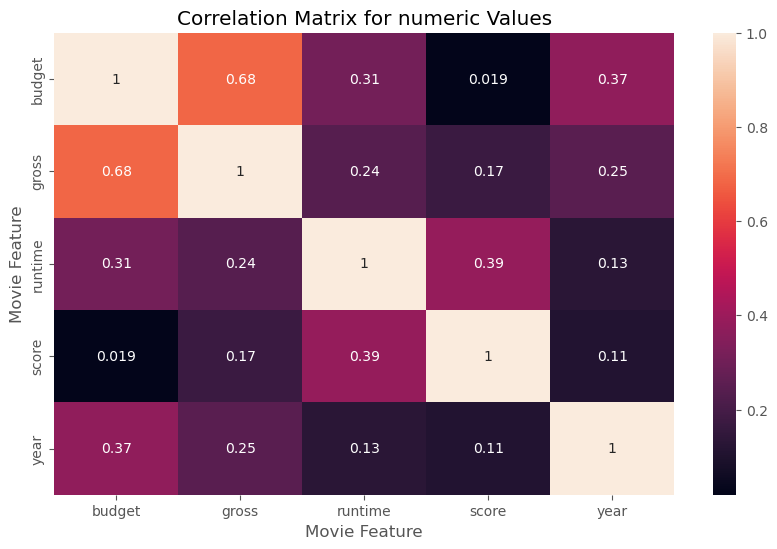

In [29]:
#Showing the Correlation Matrix
correlation_matrix = df_numeric.corr(method='pearson')

sns.heatmap(correlation_matrix, annot=True )

plt.title('Correlation Matrix for numeric Values')

plt.xlabel('Movie Feature')

plt.ylabel('Movie Feature')

plt.show()

In [33]:
# numerize the non numerical columns.

df_numerized = df

for col_name in df_numerized.columns:
    if(df_numerized[col_name].dtype =='object'):
        df_numerized[col_name] = df_numerized[col_name].astype('category')
        df_numerized[col_name] = df_numerized[col_name].cat.codes
        
df_numerized

,budget,company,country,director,genre,gross,name,rating,released,runtime,score,star,writer,year,correct_year
0,8000000,257,37,1018,1,52287414,2133,6,29,89,8.1,1150,1722,1986,0
1,15000000,668,37,1244,0,179800601,2861,4,16,110,6.9,1098,874,1986,0
2,18500000,837,37,478,0,85160248,133,6,24,137,8.4,1039,768,1986,0
3,6000000,668,37,597,4,70136369,827,5,19,103,7.8,767,928,1986,0
4,9000000,668,37,449,4,40471663,1777,5,6,96,6.8,824,928,1986,0
5,6000000,467,36,895,6,138530565,1750,6,47,120,8.1,185,1384,1986,1
6,6000000,298,37,256,6,8551228,343,6,35,120,7.8,459,409,1986,0
7,10000000,298,37,1141,0,7433663,1464,6,25,98,5.4,347,1722,1986,0
8,25000000,468,36,547,1,12729917,1314,4,22,101,7.4,270,453,1986,0
9,8800000,728,1,940,1,174635000,550,5,31,97,6.5,883,1058,1986,0


In [47]:
df

,budget,company,country,director,genre,gross,name,rating,released,runtime,score,star,writer,year,correct_year
0,8000000,Columbia Pictures Corporation,USA,Rob Reiner,Adventure,52287414,Stand by Me,R,1986-08-22,89,8.1,Wil Wheaton,Stephen King,1986,1986
1,15000000,Paramount Pictures,USA,Tony Scott,Action,179800601,Top Gun,PG,1986-05-16,110,6.9,Tom Cruise,Jim Cash,1986,1986
2,18500000,Twentieth Century Fox Film Corporation,USA,James Cameron,Action,85160248,Aliens,R,1986-07-18,137,8.4,Sigourney Weaver,James Cameron,1986,1986
3,6000000,Paramount Pictures,USA,John Hughes,Comedy,70136369,Ferris Bueller's Day Off,PG-13,1986-06-11,103,7.8,Matthew Broderick,John Hughes,1986,1986
4,9000000,Paramount Pictures,USA,Howard Deutch,Comedy,40471663,Pretty in Pink,PG-13,1986-02-28,96,6.8,Molly Ringwald,John Hughes,1986,1986
5,6000000,Hemdale,UK,Oliver Stone,Drama,138530565,Platoon,R,1987-02-06,120,8.1,Charlie Sheen,Oliver Stone,1986,1987
6,6000000,De Laurentiis Entertainment Group (DEG),USA,David Lynch,Drama,8551228,Blue Velvet,R,1986-10-23,120,7.8,Isabella Rossellini,David Lynch,1986,1986
7,10000000,De Laurentiis Entertainment Group (DEG),USA,Stephen King,Action,7433663,Maximum Overdrive,R,1986-07-25,98,5.4,Emilio Estevez,Stephen King,1986,1986
8,25000000,Henson Associates (HA),UK,Jim Henson,Adventure,12729917,Labyrinth,PG,1986-06-27,101,7.4,David Bowie,Dennis Lee,1986,1986
9,8800000,Rimfire Films,Australia,Peter Faiman,Adventure,174635000,Crocodile Dundee,PG-13,1986-09-26,97,6.5,Paul Hogan,Ken Shadie,1986,1986


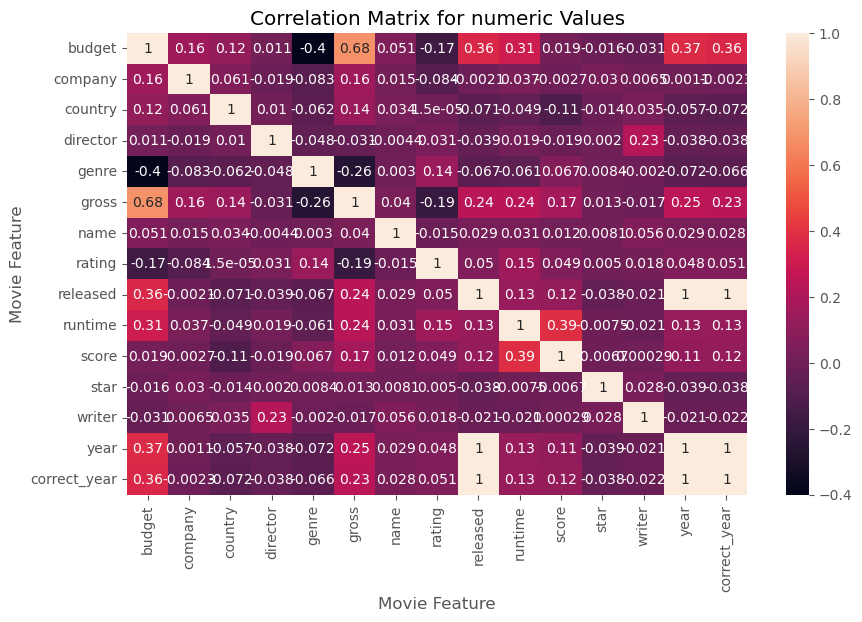

In [52]:
#Showing the Correlation Matrix for the entire table both numerica and non-numeric values 

correlation_matrix = df_numerized.corr(method='pearson')

sns.heatmap(correlation_matrix, annot=True )

plt.title('Correlation Matrix for numeric Values')

plt.xlabel('Movie Feature')

plt.ylabel('Movie Feature')

plt.show()

In [54]:
#Organize the correlation value using Unstacking

correlation_matrix_unstack = df_numerized.corr()

corr_pairs = correlation_matrix_unstack.unstack()

corr_pairs

budget        budget          1.000000
              company         0.157083
              country         0.118863
              director        0.011052
              genre          -0.401052
              gross           0.682588
              name            0.051049
              rating         -0.171070
              released        0.364690
              runtime         0.309652
              score           0.019061
              star           -0.016357
              writer         -0.031269
              year            0.374904
              correct_year    0.361727
company       budget          0.157083
              company         1.000000
              country         0.061089
              director       -0.018730
              genre          -0.083068
              gross           0.156013
              name            0.014947
              rating         -0.083646
              released       -0.002053
              runtime         0.037491
              score      

In [55]:
# sort the correlation pairs 
sorted_pairs = corr_pairs.sort_values()

sorted_pairs

genre         budget         -0.401052
budget        genre          -0.401052
genre         gross          -0.263051
gross         genre          -0.263051
              rating         -0.191666
rating        gross          -0.191666
              budget         -0.171070
budget        rating         -0.171070
country       score          -0.113568
score         country        -0.113568
rating        company        -0.083646
company       rating         -0.083646
genre         company        -0.083068
company       genre          -0.083068
genre         year           -0.072299
year          genre          -0.072299
correct_year  country        -0.072135
country       correct_year   -0.072135
released      country        -0.070944
country       released       -0.070944
genre         released       -0.066830
released      genre          -0.066830
correct_year  genre          -0.065987
genre         correct_year   -0.065987
              country        -0.062478
country       genre      

In [57]:
# sort the pairs that is greater than 0.5 i.e showing the hig correlation values.

high_corr = sorted_pairs[(sorted_pairs) > 0.4]

high_corr

gross         budget          0.682588
budget        gross           0.682588
correct_year  year            0.996846
year          correct_year    0.996846
released      year            0.996873
year          released        0.996873
released      correct_year    0.999434
correct_year  released        0.999434
budget        budget          1.000000
rating        rating          1.000000
writer        writer          1.000000
star          star            1.000000
score         score           1.000000
runtime       runtime         1.000000
released      released        1.000000
name          name            1.000000
gross         gross           1.000000
genre         genre           1.000000
director      director        1.000000
country       country         1.000000
company       company         1.000000
year          year            1.000000
correct_year  correct_year    1.000000
dtype: float64

In [ ]:
# Budget has the highest correlation to gross earnings

#Company has no/low correlation 